In [1]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

c:\Users\Mari\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Only get data analyst jobs in the US
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()

# Drop NaN values from the 'salary_year_avg' column for accurate visualization
df_DA_US = df_DA_US.dropna(subset=['salary_year_avg'])

In [5]:
df_DA_US = df_DA_US.explode('job_skills')
df_DA_US[['salary_year_avg', 'job_skills']]

,salary_year_avg,job_skills
109,89000.0,python
109,89000.0,r
109,89000.0,alteryx
109,89000.0,tableau
180,90250.0,excel
...,...,...
784882,87500.0,sql
784882,87500.0,vba
784882,87500.0,tableau
784882,87500.0,excel


In [20]:
df_DA_US_group = df_DA_US.groupby('job_skills')['salary_year_avg'].agg(['count', 'median'])
df_DA_top_pay = df_DA_US_group.sort_values(by='median', ascending = False).head(10)
df_DA_skills = df_DA_US_group.sort_values(by='count', ascending = False).head(10).sort_values(by='median', ascending = False).head(10)
df_DA_skills

,count,median
job_skills,,
python,1431,97500.00
tableau,1364,92875.00
r,893,92500.00
sql server,286,92500.00
sql,2508,91000.00
sas,926,90000.00
power bi,838,90000.00
powerpoint,462,85000.00
excel,1808,84392.00


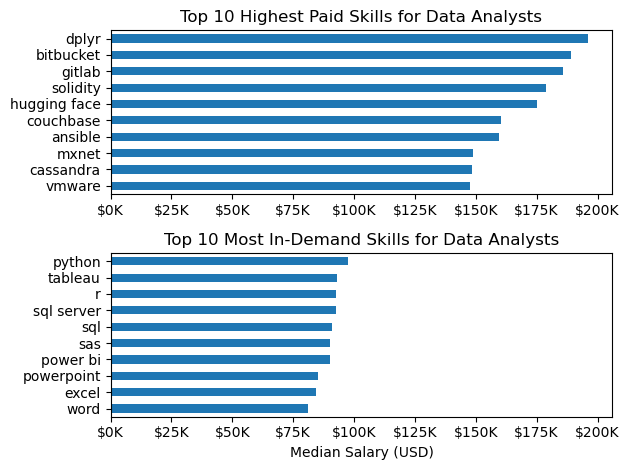

In [30]:
fig, ax = plt.subplots(2, 1)
df_DA_top_pay[::-1].plot(kind='barh', y = 'median', ax=ax[0], legend = False)
ax[0].set_title('Top 10 Highest Paid Skills for Data Analysts')
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))
df_DA_skills[::-1].plot(kind='barh', y = 'median', ax=ax[1], legend = False)
ax[1].set_title('Top 10 Most In-Demand Skills for Data Analysts')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary (USD)')
ax[1].set_xlim(ax[0].get_xlim())
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

fig.tight_layout()


In [31]:
# Only get data analyst jobs in the US
df_DA_UKR = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'Ukraine')].copy()

# Drop NaN values from the 'salary_year_avg' column for accurate visualization
df_DA_UKR = df_DA_UKR.dropna(subset=['salary_year_avg'])

In [32]:
df_DA_UKR = df_DA_UKR.explode('job_skills')
df_DA_UKR[['salary_year_avg', 'job_skills']]

,salary_year_avg,job_skills
118357,75067.5,NaN
303434,62000.0,sql
303434,62000.0,aws
303434,62000.0,redshift
303434,62000.0,tableau
303434,62000.0,power bi
518383,111175.0,tableau
544992,72900.0,sql
544992,72900.0,azure
544992,72900.0,databricks


In [33]:
df_DA_UKR_group = df_DA_UKR.groupby('job_skills')['salary_year_avg'].agg(['count', 'median'])
df_DA_top_pay_UKR = df_DA_UKR_group.sort_values(by='median', ascending = False).head(10)
df_DA_skills_UKR = df_DA_UKR_group.sort_values(by='count', ascending = False).head(10).sort_values(by='median', ascending = False).head(10)
df_DA_skills_UKR

,count,median
job_skills,,
tableau,2,86587.5
excel,1,72900.0
html,1,72900.0
flow,1,72900.0
databricks,1,72900.0
azure,1,72900.0
aws,1,62000.0
sql,3,62000.0
power bi,2,57507.0


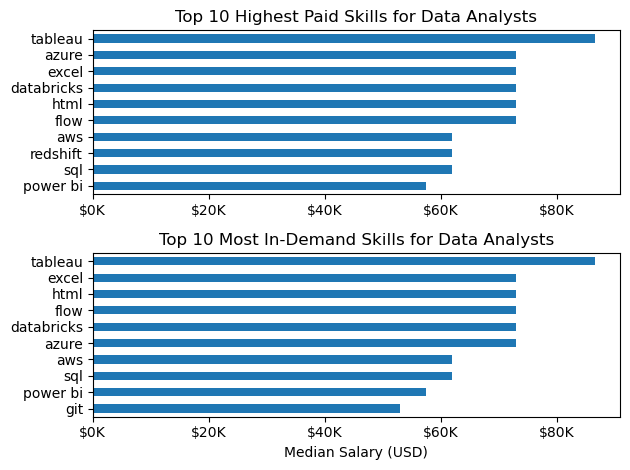

In [34]:
fig, ax = plt.subplots(2, 1)
df_DA_top_pay_UKR[::-1].plot(kind='barh', y = 'median', ax=ax[0], legend = False)
ax[0].set_title('Top 10 Highest Paid Skills for Data Analysts')
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))
df_DA_skills_UKR[::-1].plot(kind='barh', y = 'median', ax=ax[1], legend = False)
ax[1].set_title('Top 10 Most In-Demand Skills for Data Analysts')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary (USD)')
ax[1].set_xlim(ax[0].get_xlim())
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

fig.tight_layout()
